<a href="https://colab.research.google.com/github/anshubansal371/Multimodal-AI-Interview-Analyzer/blob/main/Audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report,
    confusion_matrix)
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

DATA        = '/content/drive/MyDrive/Data'
MODEL_SAVE  = '/content/drive/MyDrive/Models'
ARRAYS_PATH = '/content/drive/MyDrive/Arrays'
AUDIO_ARRAYS= f'{ARRAYS_PATH}/audio'
os.makedirs(MODEL_SAVE,   exist_ok=True)
os.makedirs(AUDIO_ARRAYS, exist_ok=True)

print(f"✅ TF      : {tf.__version__}")
print(f"✅ GPU     : {tf.config.list_physical_devices('GPU')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ TF      : 2.20.0
✅ GPU     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Copy audio to local disk ───────────────────────────
import shutil

for name, src in {
    'ravdess': f'{DATA}/ravdess',
    'tess'   : f'{DATA}/tess',
    'crema_d': f'{DATA}/CREMA-D'
}.items():
    dst = f'/content/{name}'
    if not os.path.exists(dst):
        print(f"Copying {name}...")
        shutil.copytree(src, dst)
        print(f"✅ {name} done!")
    else:
        print(f"✅ {name} already local!")

✅ ravdess already local!
✅ tess already local!
Copying crema_d...
✅ crema_d done!


In [ ]:
# ── Load all file paths + labels ──────────────────────
# RAVDESS
RAV_PATH = '/content/ravdess'
RAVDESS_EMOTIONS = {
    '01':'neutral','02':'neutral', # calm→neutral
    '03':'happy',  '04':'sad',
    '05':'angry',  '06':'fearful',
    '07':'disgust','08':'surprised'}

rav_files, rav_labels = [], []
for actor in sorted(os.listdir(RAV_PATH)):
    ap = os.path.join(RAV_PATH, actor)
    if not os.path.isdir(ap): continue
    for fname in os.listdir(ap):
        if not fname.endswith('.wav'): continue
        parts = fname.replace('.wav','').split('-')
        if len(parts) >= 3:
            em = RAVDESS_EMOTIONS.get(
                parts[2], 'unknown')
            if em != 'unknown':
                rav_files.append(
                    os.path.join(ap, fname))
                rav_labels.append(em)

# TESS
TESS_PATH = '/content/tess'
TESS_MAP  = {
    'angry':'angry','disgust':'disgust',
    'fear':'fearful','happy':'happy',
    'neutral':'neutral','sad':'sad',
    'ps':'surprised',
    'pleasant_surprise':'surprised'}

tess_files, tess_labels = [], []
tess_inner = TESS_PATH
items = os.listdir(TESS_PATH)
if len(items)==1:
    inner = os.path.join(TESS_PATH, items[0])
    if os.path.isdir(inner):
        tess_inner = inner

for folder in os.listdir(tess_inner):
    fp = os.path.join(tess_inner, folder)
    if not os.path.isdir(fp): continue
    parts = folder.lower().split('_')
    em = 'surprised' if 'pleasant' in \
        folder.lower() else parts[-1]
    em = TESS_MAP.get(em, em)
    for fname in os.listdir(fp):
        if fname.endswith('.wav'):
            tess_files.append(
                os.path.join(fp, fname))
            tess_labels.append(em)

# CREMA-D
CREMA_PATH = '/content/crema_d'
CREMA_MAP  = {
    'ANG':'angry','DIS':'disgust',
    'FEA':'fearful','HAP':'happy',
    'NEU':'neutral','SAD':'sad'}

crema_files, crema_labels = [], []
crema_dir = CREMA_PATH
for item in os.listdir(CREMA_PATH):
    full = os.path.join(CREMA_PATH, item)
    if os.path.isdir(full):
        crema_dir = full
        break

for fname in os.listdir(crema_dir):
    if not (fname.endswith('.wav') or
            fname.endswith('.flac')): continue
    parts = fname.replace('.wav','').replace(
        '.flac','').split('_')
    if len(parts) >= 3:
        em = CREMA_MAP.get(parts[2], 'unknown')
        if em != 'unknown':
            crema_files.append(
                os.path.join(crema_dir, fname))
            crema_labels.append(em)

# Combine
all_files  = rav_files + tess_files + crema_files
all_labels = rav_labels+tess_labels+crema_labels

AUDIO_EMOTIONS = sorted(set(all_labels))
AUDIO_TO_IDX   = {e:i for i,e in
                  enumerate(AUDIO_EMOTIONS)}
IDX_TO_AUDIO   = {i:e for i,e in
                  enumerate(AUDIO_EMOTIONS)}
NUM_CLASSES    = len(AUDIO_EMOTIONS)

print(f"✅ Total files  : {len(all_files):,}")
print(f"✅ Num classes  : {NUM_CLASSES}")
print(f"   Emotions     : {AUDIO_EMOTIONS}")
print(f"\nDistribution:")
for e, c in Counter(all_labels).items():
    print(f"  {e:10s} : {c:,}")

✅ Total files  : 8,311
✅ Num classes  : 7
   Emotions     : ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

Distribution:
  sad        : 1,387
  surprised  : 112
  angry      : 1,388
  disgust    : 1,383
  happy      : 1,390
  neutral    : 1,263
  fearful    : 1,388


In [ ]:
# ── Apply merge: surprised → happy ────────────────────
FINAL_MERGE = {
    'angry':    'angry',
    'disgust':  'disgust',
    'fearful':  'fearful',
    'happy':    'happy',
    'neutral':  'neutral',
    'sad':      'sad',
    'surprised':'happy'   # merge → happy
}

all_labels_final = [
    FINAL_MERGE[l] for l in all_labels]

AUDIO_EMOTIONS = sorted(set(all_labels_final))
AUDIO_TO_IDX   = {e:i for i,e in
                  enumerate(AUDIO_EMOTIONS)}
IDX_TO_AUDIO   = {i:e for i,e in
                  enumerate(AUDIO_EMOTIONS)}
NUM_CLASSES    = len(AUDIO_EMOTIONS)

print(f"✅ Final classes : {NUM_CLASSES}")
print(f"   Emotions      : {AUDIO_EMOTIONS}")
print(f"\nFinal distribution:")
from collections import Counter
counts = Counter(all_labels_final)
for e, c in sorted(counts.items()):
    print(f"  {e:10s} : {c:,}")

✅ Final classes : 6
   Emotions      : ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']

Final distribution:
  angry      : 1,388
  disgust    : 1,383
  fearful    : 1,388
  happy      : 1,502
  neutral    : 1,263
  sad        : 1,387


In [ ]:
# ── Extract mel spectrograms ───────────────────────────
from PIL import Image

MEL_PATH = f'{AUDIO_ARRAYS}/mel_specs.npy'
LAB_PATH = f'{AUDIO_ARRAYS}/mel_labels.npy'

IMG_H = 64
IMG_W = 64
SR    = 22050
DUR   = 3

def extract_melspec(fpath):
    try:
        y, sr = librosa.load(
            fpath, sr=SR, duration=DUR)
        target = SR * DUR
        if len(y) < target:
            y = np.pad(y,
                (0, target-len(y)),
                mode='constant')
        else:
            y = y[:target]

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=IMG_H,
            n_fft=2048, hop_length=512)
        mel_db = librosa.power_to_db(
            mel, ref=np.max)

        mel_img = np.array(
            Image.fromarray(mel_db).resize(
                (IMG_W, IMG_H)))
        mel_norm = (mel_img - mel_img.min()) / \
            (mel_img.max()-mel_img.min()+1e-8)

        return mel_norm.reshape(
            IMG_H, IMG_W, 1).astype(np.float32)
    except:
        return None

if os.path.exists(MEL_PATH):
    print("✅ Loading saved mel specs...")
    X_mel = np.load(MEL_PATH)
    y_mel = np.load(LAB_PATH)
else:
    print("Extracting mel spectrograms...")
    print("(~15 min — once only)")
    X_mel, y_mel = [], []

    for i, (fp, lb) in enumerate(
            zip(all_files, all_labels_final)):
        spec = extract_melspec(fp)
        if spec is not None:
            X_mel.append(spec)
            y_mel.append(AUDIO_TO_IDX[lb])
        if (i+1) % 1000 == 0:
            print(f"  {i+1:,}/{len(all_files):,}")

    X_mel = np.array(X_mel, dtype=np.float32)
    y_mel = np.array(y_mel, dtype=np.int32)
    np.save(MEL_PATH, X_mel)
    np.save(LAB_PATH, y_mel)
    print(f"✅ Saved!")

print(f"✅ X_mel : {X_mel.shape}")
print(f"✅ y_mel : {y_mel.shape}")
print(f"   Classes: {NUM_CLASSES}")

Extracting mel spectrograms...
(~15 min — once only)
  1,000/8,311
  2,000/8,311
  3,000/8,311
  4,000/8,311
  5,000/8,311
  6,000/8,311
  7,000/8,311
  8,000/8,311
✅ Saved!
✅ X_mel : (8309, 64, 64, 1)
✅ y_mel : (8309,)
   Classes: 6


In [ ]:
# ── Train/test split ──────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X_tr, X_te, y_tr, y_te = train_test_split(
    X_mel, y_mel,
    test_size=0.2,
    random_state=42,
    stratify=y_mel)

y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
y_te_cat = to_categorical(y_te, NUM_CLASSES)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr)
class_weight_dict = dict(enumerate(class_weights))

print(f"✅ Train : {X_tr.shape}")
print(f"✅ Test  : {X_te.shape}")
print(f"\nClass weights:")
for i, w in class_weight_dict.items():
    print(f"  {IDX_TO_AUDIO[i]:10s}: {w:.3f}")

✅ Train : (6647, 64, 64, 1)
✅ Test  : (1662, 64, 64, 1)

Class weights:
  angry     : 0.998
  disgust   : 1.002
  fearful   : 0.998
  happy     : 0.922
  neutral   : 1.097
  sad       : 0.998


In [ ]:
# ── Build Mel CNN ─────────────────────────────────────
def build_mel_cnn(num_classes):
    inputs = tf.keras.Input(shape=(64, 64, 1))

    # Block 1
    x = layers.Conv2D(32,(3,3),
        padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32,(3,3),
        padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64,(3,3),
        padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64,(3,3),
        padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128,(3,3),
        padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = layers.Conv2D(256,(3,3),
        padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Classifier
    x = layers.Dense(256,
        activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128,
        activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(
        num_classes,
        activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=0.1),
        metrics=['accuracy'])
    return model

audio_model = build_mel_cnn(NUM_CLASSES)
print(f"✅ Mel CNN built")
print(f"   Params : {audio_model.count_params():,}")
print(f"   Input  : (64, 64, 1)")
print(f"   Classes: {NUM_CLASSES}")

✅ Mel CNN built
   Params : 536,806
   Input  : (64, 64, 1)
   Classes: 6


In [ ]:
# ── Train ─────────────────────────────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    width_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest')

train_gen = train_datagen.flow(
    X_tr, y_tr_cat,
    batch_size=64, shuffle=True)

callbacks = [
    ModelCheckpoint(
        f'{MODEL_SAVE}/audio_model_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1)]

print("🚀 Training Mel Spectrogram CNN")
print(f"   Input   : 64x64 mel images")
print(f"   Classes : {NUM_CLASSES}")
print(f"   Train   : {len(X_tr):,}")

history = audio_model.fit(
    train_gen,
    epochs=50,
    validation_data=(X_te, y_te_cat),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1)

best = max(history.history['val_accuracy'])
print(f"\n✅ Best : {best*100:.2f}%")

🚀 Training Mel Spectrogram CNN
   Input   : 64x64 mel images
   Classes : 6
   Train   : 6,647
Epoch 1/50
103/104 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.2280 - loss: 2.3233
Epoch 1: val_accuracy improved from None to 0.16667, saving model to /content/drive/MyDrive/Models/audio_model_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Models/audio_model_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 40s 194ms/step - accuracy: 0.2547 - loss: 2.1084 - val_accuracy: 0.1667 - val_loss: 2.8954 - learning_rate: 0.0010
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2843 - loss: 1.8260
Epoch 2: val_accuracy improved from 0.16667 to 0.20096, saving model to /content/drive/MyDrive/Models/audio_model_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Models/audio_model_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.2913 - loss: 1.7948 - val_accuracy: 0.2010 - val_loss: 3.5231 - learning_rate: 0.0010
Epoch 3/50
103/104 ━━

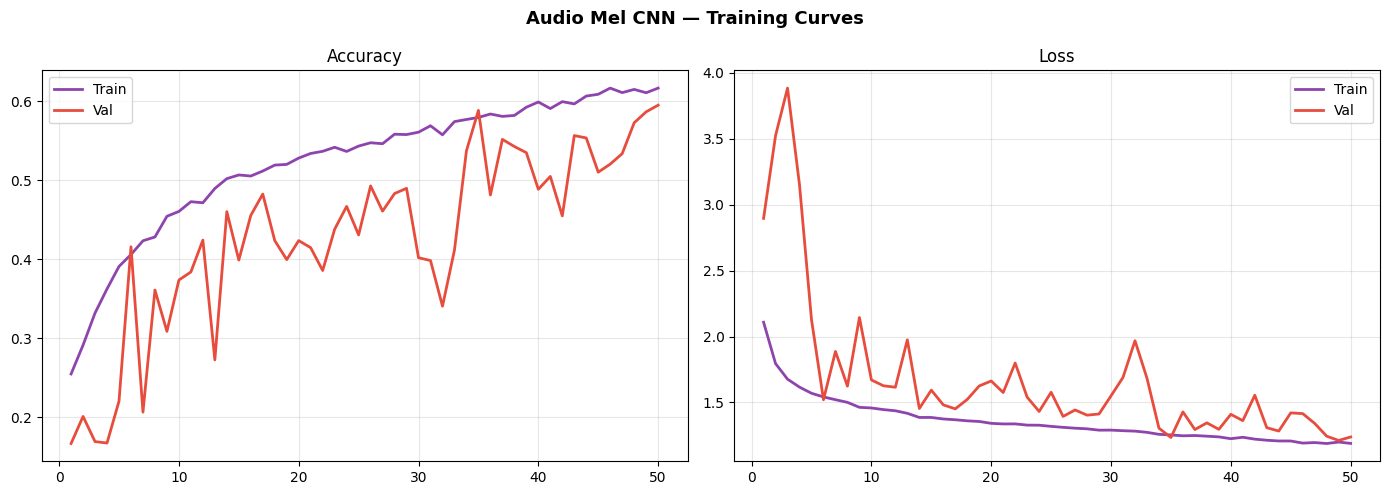

✅ Test Accuracy : 59.51%
              precision    recall  f1-score   support

       angry       0.71      0.75      0.73       277
     disgust       0.80      0.31      0.45       277
     fearful       0.52      0.55      0.54       278
       happy       0.64      0.53      0.58       300
     neutral       0.51      0.92      0.66       253
         sad       0.56      0.53      0.55       277

    accuracy                           0.60      1662
   macro avg       0.62      0.60      0.58      1662
weighted avg       0.63      0.60      0.58      1662



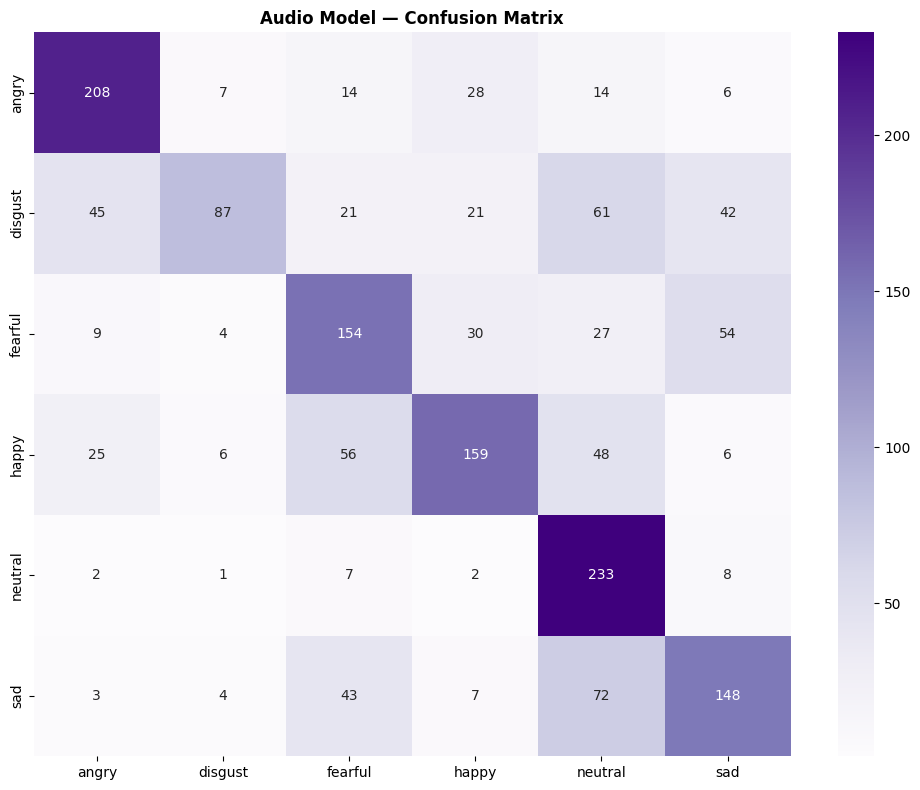

✅ DAY 3 COMPLETE — AUDIO MODULE DONE
  Model    : Mel Spectrogram CNN
  Input    : 64x64 mel images
  Classes  : 6
  Emotions : ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']
  Accuracy : 59.51%
  Saved    : audio_model_final.keras

  Say 'Start Day 4' → Text/NLP module


In [ ]:
# ── Plot + Evaluate + Save ─────────────────────────────
acc   = history.history['accuracy']
val   = history.history['val_accuracy']
loss  = history.history['loss']
vloss = history.history['val_loss']
ep    = range(1, len(acc)+1)

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Audio Mel CNN — Training Curves',
             fontsize=13, fontweight='bold')
axes[0].plot(ep, acc,  color='#8e44ad',
    linewidth=2, label='Train')
axes[0].plot(ep, val,  color='#e74c3c',
    linewidth=2, label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(ep, loss,  color='#8e44ad',
    linewidth=2, label='Train')
axes[1].plot(ep, vloss, color='#e74c3c',
    linewidth=2, label='Val')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate
test_loss, test_acc = audio_model.evaluate(
    X_te, y_te_cat, verbose=0)
print(f"✅ Test Accuracy : {test_acc*100:.2f}%")

y_pred     = audio_model.predict(
    X_te, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)

print(classification_report(
    y_te, y_pred_cls,
    target_names=list(IDX_TO_AUDIO.values())))

cm = confusion_matrix(y_te, y_pred_cls)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
    xticklabels=IDX_TO_AUDIO.values(),
    yticklabels=IDX_TO_AUDIO.values(),
    cmap='Purples')
plt.title('Audio Model — Confusion Matrix',
          fontweight='bold')
plt.tight_layout()
plt.show()

# Save
audio_model.save(
    f'{MODEL_SAVE}/audio_model_final.keras')

import json
audio_meta = {
    'emotions'   : IDX_TO_AUDIO,
    'num_classes': NUM_CLASSES,
    'img_h'      : 64,
    'img_w'      : 64,
    'sample_rate': 22050,
    'duration'   : 3
}
with open(f'{AUDIO_ARRAYS}/audio_meta.json',
          'w') as f:
    json.dump(audio_meta, f)

print("=" * 55)
print("✅ DAY 3 COMPLETE — AUDIO MODULE DONE")
print("=" * 55)
print(f"  Model    : Mel Spectrogram CNN")
print(f"  Input    : 64x64 mel images")
print(f"  Classes  : {NUM_CLASSES}")
print(f"  Emotions : {list(IDX_TO_AUDIO.values())}")
print(f"  Accuracy : {test_acc*100:.2f}%")
print(f"  Saved    : audio_model_final.keras")
print()
print("  Say 'Start Day 4' → Text/NLP module")

## this is the previous technique which has 56 percent accuracy

In [ ]:
# ── MFCC Feature Extraction ───────────────────────────
def extract_features(file_path,
                     n_mfcc=40,
                     sr=22050,
                     duration=3):
    try:
        # Load audio — fixed duration
        y, sr = librosa.load(
            file_path, sr=sr,
            duration=duration)

        # Pad if shorter than duration
        target_len = sr * duration
        if len(y) < target_len:
            y = np.pad(y,
                (0, target_len - len(y)),
                mode='constant')
        else:
            y = y[:target_len]

        # MFCC — 40 coefficients
        mfcc = librosa.feature.mfcc(
            y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_delta  = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(
            mfcc, order=2)

        # Pitch (fundamental frequency)
        pitches, magnitudes = librosa.piptrack(
            y=y, sr=sr)
        pitch_mean = pitches[pitches > 0].mean() \
            if pitches[pitches > 0].size > 0 else 0

        # Zero crossing rate
        zcr = librosa.feature.zero_crossing_rate(y)

        # Spectral energy (RMS)
        rms = librosa.feature.rms(y=y)

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(
            mel, ref=np.max)

        # Stack all features
        features = np.vstack([
            mfcc,           # 40 x T
            mfcc_delta,     # 40 x T
            mfcc_delta2,    # 40 x T
            zcr,            # 1  x T
            rms             # 1  x T
        ])  # → 122 x T

        # Mean + std across time
        feat_mean = np.mean(features, axis=1)
        feat_std  = np.std(features,  axis=1)
        feat_vec  = np.concatenate(
            [feat_mean, feat_std])  # 244-dim

        return feat_vec

    except Exception as e:
        return None

# Test on one file
test_feat = extract_features(all_files[0])
print(f"✅ Feature extraction works!")
print(f"   Feature vector shape : {test_feat.shape}")
print(f"   Feature dim          : {len(test_feat)}")

✅ Feature extraction works!
   Feature vector shape : (244,)
   Feature dim          : 244


In [ ]:
# ── Extract features for all 9,967 files ──────────────
# Takes ~10-15 min — runs once then saves to Drive

AUDIO_ARRAYS = f'{ARRAYS_PATH}/audio'
os.makedirs(AUDIO_ARRAYS, exist_ok=True)

feat_path = f'{AUDIO_ARRAYS}/X_audio.npy'
lab_path  = f'{AUDIO_ARRAYS}/y_audio.npy'

if os.path.exists(feat_path):
    print("✅ Audio features already saved — loading!")
    X_audio = np.load(feat_path)
    y_audio = np.load(lab_path)
else:
    print(f"Extracting features from "
          f"{len(all_files):,} files...")
    print("(Takes ~10-15 min — runs only once)")

    X_audio = []
    y_audio = []
    failed  = 0

    for i, (fpath, label) in enumerate(
            zip(all_files, all_labels)):
        feat = extract_features(fpath)
        if feat is not None:
            X_audio.append(feat)
            y_audio.append(AUDIO_TO_IDX[label])
        else:
            failed += 1

        if (i+1) % 500 == 0:
            print(f"  Processed {i+1:,} / "
                  f"{len(all_files):,} files")

    X_audio = np.array(X_audio, dtype=np.float32)
    y_audio = np.array(y_audio, dtype=np.int32)

    # Save immediately
    np.save(feat_path, X_audio)
    np.save(lab_path,  y_audio)
    print(f"\n✅ Features saved!")
    print(f"   Failed : {failed} files")

print(f"✅ X_audio : {X_audio.shape}")
print(f"✅ y_audio : {y_audio.shape}")
print(f"   Classes : {len(AUDIO_TO_IDX)}")

Extracting features from 9,967 files...
(Takes ~10-15 min — runs only once)
  Processed 500 / 9,967 files
  Processed 1,000 / 9,967 files
  Processed 1,500 / 9,967 files
  Processed 2,000 / 9,967 files
  Processed 2,500 / 9,967 files
  Processed 3,000 / 9,967 files
  Processed 3,500 / 9,967 files
  Processed 4,000 / 9,967 files
  Processed 4,500 / 9,967 files
  Processed 5,000 / 9,967 files
  Processed 5,500 / 9,967 files
  Processed 6,000 / 9,967 files
  Processed 6,500 / 9,967 files
  Processed 7,000 / 9,967 files
  Processed 7,500 / 9,967 files
  Processed 8,000 / 9,967 files
  Processed 8,500 / 9,967 files
  Processed 9,000 / 9,967 files
  Processed 9,500 / 9,967 files

✅ Features saved!
   Failed : 0 files
✅ X_audio : (9967, 244)
✅ y_audio : (9967,)
   Classes : 8


In [ ]:
# ── Merge calm into neutral using STRING labels ─────

all_labels_fixed = []

for label in all_labels:

    if label == 'calm':
        label = 'neutral'

    all_labels_fixed.append(label)

print("✅ Calm merged into Neutral")

✅ Calm merged into Neutral


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode labels
encoder = LabelEncoder()

y_audio = encoder.fit_transform(all_labels_fixed)

# Class names
class_names = encoder.classes_

print("✅ Classes:")
print(class_names)

print("\n✅ Total Classes:", len(class_names))

✅ Classes:
['angry' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

✅ Total Classes: 7


In [ ]:
# ── Normalize + Split ─────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_audio)

# Save scaler for inference
import pickle
scaler_path = f'{AUDIO_ARRAYS}/audio_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler saved")

# Train/test split — stratified
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_audio,
    test_size=0.2,
    random_state=42,
    stratify=y_audio)

print(f"✅ Train : {X_tr.shape}")
print(f"✅ Test  : {X_te.shape}")
print(f"\nTrain distribution:")
for i, name in IDX_TO_AUDIO.items():
    count = np.sum(y_tr == i)
    print(f"  {name:10s} : {count:,}")

✅ Scaler saved
✅ Train : (7973, 244)
✅ Test  : (1994, 244)

Train distribution:
  angry      : 1,330
  disgust    : 1,330
  fearful    : 1,330
  happy      : 1,239
  neutral    : 1,100
  sad        : 1,330
  surprised  : 314


In [ ]:
# ── Rebuild AUDIO_TO_IDX without calm ───────────────

AUDIO_TO_IDX = {
    'angry'    : 0,
    'disgust'  : 1,
    'fearful'  : 2,
    'happy'    : 3,
    'neutral'  : 4,
    'sad'      : 5,
    'surprised': 6
}

# Reverse mapping
IDX_TO_AUDIO = {
    v:k for k,v in AUDIO_TO_IDX.items()
}

print("✅ AUDIO_TO_IDX fixed:\n")
print(AUDIO_TO_IDX)

print("\n✅ IDX_TO_AUDIO fixed:\n")
print(IDX_TO_AUDIO)

✅ AUDIO_TO_IDX fixed:

{'angry': 0, 'disgust': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}

✅ IDX_TO_AUDIO fixed:

{0: 'angry', 1: 'disgust', 2: 'fearful', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprised'}


In [ ]:
# ── Reshape for BiLSTM ────────────────────────────────
# BiLSTM expects (samples, timesteps, features)
# We reshape 244-dim vector → (4, 61) sequences

TIMESTEPS = 61
FEATURES  = X_tr.shape[1] // TIMESTEPS

X_tr_lstm = X_tr.reshape(
    X_tr.shape[0], TIMESTEPS, FEATURES)
X_te_lstm = X_te.reshape(
    X_te.shape[0], TIMESTEPS, FEATURES)

NUM_CLASSES = len(AUDIO_TO_IDX)

y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
y_te_cat = to_categorical(y_te, NUM_CLASSES)

# Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr)
class_weight_dict = dict(enumerate(class_weights))

print(f"✅ X_tr_lstm : {X_tr_lstm.shape}")
print(f"✅ X_te_lstm : {X_te_lstm.shape}")
print(f"   Timesteps : {TIMESTEPS}")
print(f"   Features  : {FEATURES}")
print(f"   Classes   : {NUM_CLASSES}")
print(f"\n✅ Class weights:")
for i, w in class_weight_dict.items():
    print(f"   {IDX_TO_AUDIO[i]:10s} : {w:.3f}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import l2
# =========================================================
# CUSTOM FOCAL LOSS
# =========================================================

def focal_loss(gamma=2.0, alpha=0.25):

    def loss(y_true, y_pred):

        epsilon = 1e-7

        y_pred = tf.clip_by_value(
            y_pred,
            epsilon,
            1.0 - epsilon
        )

        cross_entropy = -y_true * tf.math.log(y_pred)

        weight = alpha * tf.pow(
            1 - y_pred,
            gamma
        )

        loss = weight * cross_entropy

        return tf.reduce_mean(
            tf.reduce_sum(loss, axis=1)
        )

    return loss

# =========================================================
# ATTENTION BLOCK
# =========================================================

class AttentionBlock(layers.Layer):

    def __init__(self):
        super(AttentionBlock, self).__init__()

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(1,),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):

        e = tf.matmul(x, self.W) + self.b

        a = tf.nn.softmax(e, axis=1)

        output = tf.reduce_sum(
            x * a,
            axis=1
        )

        return output

# =========================================================
# RESIDUAL CNN BLOCK
# =========================================================

def residual_block(x, filters):

    shortcut = x

    # Conv Layer 1
    x = layers.Conv1D(
        filters,
        kernel_size=3,
        padding='same'
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(tf.nn.gelu)(x)

    # Conv Layer 2
    x = layers.Conv1D(
        filters,
        kernel_size=3,
        padding='same'
    )(x)

    x = layers.BatchNormalization()(x)

    # Match shortcut channels
    if shortcut.shape[-1] != filters:

        shortcut = layers.Conv1D(
            filters,
            kernel_size=1,
            padding='same'
        )(shortcut)

    # Residual Addition
    x = layers.Add()([x, shortcut])

    x = layers.Activation(tf.nn.gelu)(x)

    return x

# =========================================================
# BUILD IMPROVED MODEL
# =========================================================

def build_improved_model(
        timesteps,
        features,
        num_classes
):

    inputs = tf.keras.Input(
        shape=(timesteps, features)
    )

    # =====================================================
    # INITIAL CNN
    # =====================================================

    x = layers.Conv1D(
        filters=128,
        kernel_size=3,
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(
        tf.nn.gelu
    )(x)

    x = layers.MaxPooling1D(
        pool_size=2
    )(x)

    x = layers.Dropout(0.2)(x)

    # =====================================================
    # RESIDUAL BLOCK 1
    # =====================================================

    x = residual_block(x, 128)

    x = layers.MaxPooling1D(
        pool_size=2
    )(x)

    x = layers.Dropout(0.2)(x)

    # =====================================================
    # RESIDUAL BLOCK 2
    # =====================================================

    x = residual_block(x, 256)

    x = layers.Dropout(0.2)(x)

    # =====================================================
    # SINGLE LSTM
    # =====================================================

    x = layers.LSTM(
        64,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.1
    )(x)

    # =====================================================
    # ATTENTION
    # =====================================================

    x = AttentionBlock()(x)

    # =====================================================
    # DENSE BLOCK
    # =====================================================

    x = layers.Dense(
        256,
        kernel_regularizer=l2(0.001)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(
        tf.nn.gelu
    )(x)

    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128)(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(
        tf.nn.gelu
    )(x)

    x = layers.Dropout(0.2)(x)

    # =====================================================
    # OUTPUT
    # =====================================================

    outputs = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    # =====================================================
    # BUILD MODEL
    # =====================================================

    model = Model(
        inputs,
        outputs
    )

    # =====================================================
    # COSINE LEARNING RATE
    # =====================================================

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=3e-4,
        decay_steps=1000
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr_schedule
    )

    # =====================================================
    # COMPILE
    # =====================================================

    model.compile(

        optimizer=optimizer,

        loss=focal_loss(
            gamma=2.0,
            alpha=0.25
        ),

        metrics=['accuracy']
    )

    return model

# =========================================================
# CREATE MODEL
# =========================================================

audio_model = build_improved_model(
    TIMESTEPS,
    FEATURES,
    NUM_CLASSES
)

# =========================================================
# MODEL SUMMARY
# =========================================================

audio_model.summary()

In [ ]:
# ── Train LSTM ──────────────────────────────────────
callbacks = [
    ModelCheckpoint(
        f'{MODEL_SAVE}/audio_model_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1)]

print("🚀 Trainin Audio Model")
print(f"   Classes    : {NUM_CLASSES}")
print(f"   Train clips: {len(X_tr_lstm):,}")
print(f"   Batch size : 64")
print(f"   Max epochs : 100")
print(f"   Expected   : 75-85% accuracy")
print(f"   Time/epoch : ~30 sec")

history = audio_model.fit(
    X_tr_lstm, y_tr_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X_te_lstm, y_te_cat),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1)

best = max(history.history['val_accuracy'])
print(f"\n✅ Best val accuracy : {best*100:.2f}%")

🚀 Training BiLSTM Audio Model
   Classes    : 7
   Train clips: 7,973
   Batch size : 64
   Max epochs : 100
   Expected   : 75-85% accuracy
   Time/epoch : ~30 sec
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1753 - loss: 2.0240
Epoch 1: val_accuracy improved from None to 0.19559, saving model to /content/drive/MyDrive/Models/audio_model_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Models/audio_model_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.1758 - loss: 2.0088 - val_accuracy: 0.1956 - val_loss: 1.9765 - learning_rate: 3.0000e-04
Epoch 2/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2052 - loss: 1.9182
Epoch 2: val_accuracy improved from 0.19559 to 0.31695, saving model to /content/drive/MyDrive/Models/audio_model_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Models/audio_model_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2181 - loss: 1.8909 - val_accuracy:

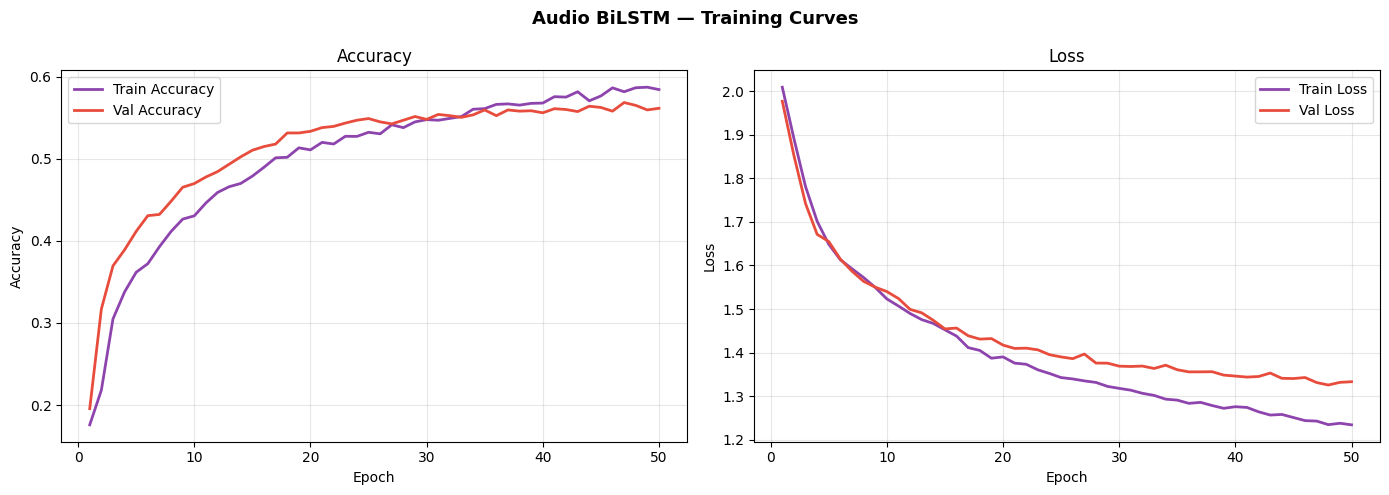

✅ Test Accuracy : 56.87%

Classification Report:
              precision    recall  f1-score   support

       angry       0.69      0.77      0.73       333
     disgust       0.56      0.42      0.48       333
     fearful       0.60      0.38      0.47       333
       happy       0.53      0.48      0.50       309
     neutral       0.46      0.66      0.54       275
         sad       0.55      0.62      0.59       333
   surprised       0.66      0.91      0.76        78

    accuracy                           0.57      1994
   macro avg       0.58      0.61      0.58      1994
weighted avg       0.57      0.57      0.56      1994



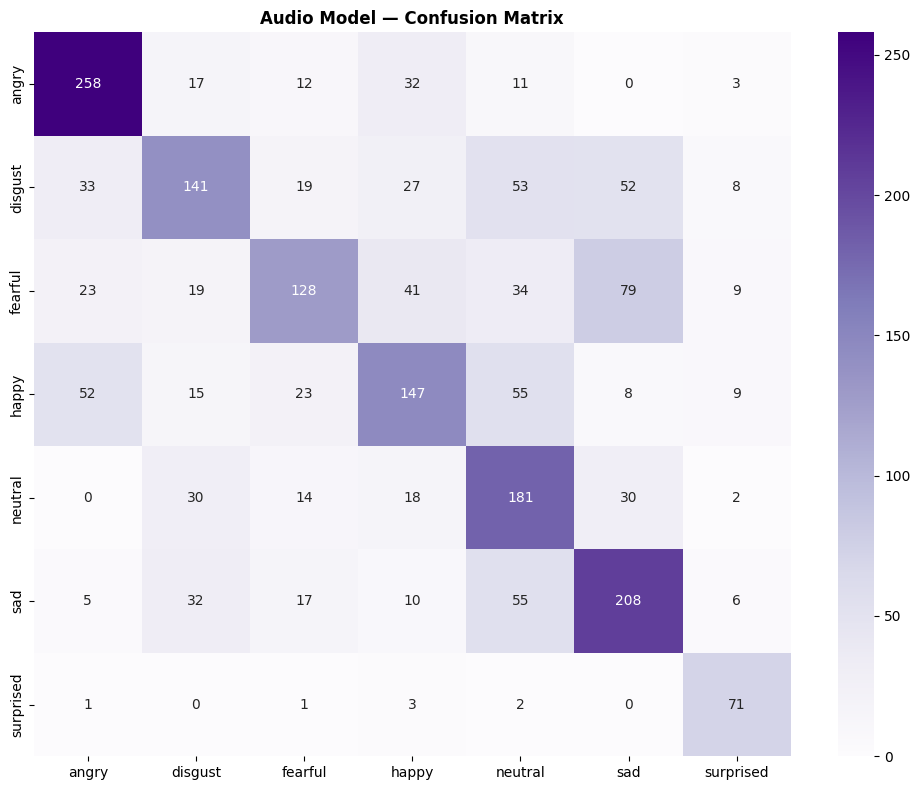

In [ ]:
# ── Plot curves ────────────────────────────────────────
acc   = history.history['accuracy']
val   = history.history['val_accuracy']
loss  = history.history['loss']
vloss = history.history['val_loss']
epochs = range(1, len(acc)+1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Audio BiLSTM — Training Curves',
             fontsize=13, fontweight='bold')

axes[0].plot(epochs, acc,
             color='#8e44ad', linewidth=2,
             label='Train Accuracy')
axes[0].plot(epochs, val,
             color='#e74c3c', linewidth=2,
             label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, loss,
             color='#8e44ad', linewidth=2,
             label='Train Loss')
axes[1].plot(epochs, vloss,
             color='#e74c3c', linewidth=2,
             label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate
test_loss, test_acc = audio_model.evaluate(
    X_te_lstm, y_te_cat, verbose=0)
print(f"✅ Test Accuracy : {test_acc*100:.2f}%")

# Confusion matrix
y_pred = audio_model.predict(
    X_te_lstm, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_te, y_pred_classes,
    target_names=list(IDX_TO_AUDIO.values())))

cm = confusion_matrix(y_te, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
    xticklabels=IDX_TO_AUDIO.values(),
    yticklabels=IDX_TO_AUDIO.values(),
    cmap='Purples')
plt.title('Audio Model — Confusion Matrix',
          fontweight='bold')
plt.tight_layout()
plt.show()